# Module 24 — Test-Time Compute Scaling: A Second Axis

**Part VI · Reasoning, Alignment & Generation · 30–35 min**

---

For about a decade, "scaling" in deep learning meant exactly one thing: **more training compute**. Bigger models. More data. Longer pretraining runs. Kaplan 2020, Chinchilla 2022, the whole song. The scaling laws were tidy, the loss curves were smooth, and every chart had `parameters` on the x-axis.

Then, in late 2024, the field tripped over a second axis.

It started with OpenAI's o1, which was allowed to "think" for tens of thousands of hidden tokens before answering. Then DeepSeek-R1 made it open-source and obvious. Then Snell et al. published *"Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters"* — and the title is the thesis. **A 32B reasoner with a 10K-token thinking budget can outperform a 405B model that answers immediately on hard math.** Same FLOPs, completely different allocation.

This module is about that allocation. We will:

1. Plot the two-axis scaling surface: accuracy as a function of *both* training compute and test-time compute.
2. Sweep a thinking budget across three problem difficulties and watch the curves diverge.
3. Look at the cheapest form of test-time compute — **best-of-N sampling with a verifier** — and the verifier-free version, **self-consistency**.
4. Sketch the **compute-optimal frontier** from Snell 2024: easy problems want best-of-N; hard problems want long reasoning + tree search.
5. Plot the **Densing Law**: 8B models in 2026 match 70B models from 2024.
6. Break it on purpose — clip the budget on hard problems, blow the budget on easy ones, watch waste in both directions.

Everything is canned. No GPUs, no API keys, no waiting. The shapes of the curves are taken from published results (Snell 2024, DeepSeek-R1 tech report, OpenAI o1 system card, Densing Law paper) and reproduced with NumPy.


## 1 · The old picture: one axis, one law

Kaplan et al. 2020 wrote down a power law: pretraining loss falls as `L(N, D, C) ∝ C^{-α}` where `C` is training compute. Chinchilla refined the exponents and balanced `N` (parameters) against `D` (tokens). For five years that was the whole story. Want a better model? Spend more compute *during training*.

The implicit assumption was that **inference is cheap and fixed**. You train once, you serve forever, you generate a few hundred tokens per query, done. Test-time compute per query was a constant. It didn't appear in the scaling law because nobody varied it.

That assumption broke when reasoning models started spending 10,000+ tokens on a single AIME problem. Suddenly inference compute per query wasn't a constant — it was a *dial*. And turning the dial up turned out to do something the old law couldn't predict.


## 2 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(2026)
print("ready")

ready


## 3 · Two axes, one accuracy

Let's draw the new picture directly. We model accuracy on a hard reasoning task as a function of two log-compute variables: `log10(train_FLOPs)` and `log10(test_FLOPs_per_query)`. The functional form is a saturating sigmoid in *both* directions, with a small interaction term (training compute and test-time compute partially substitute for each other — that's the whole punchline of Snell 2024).

This is a stylized model, not a fit, but the shape is right.

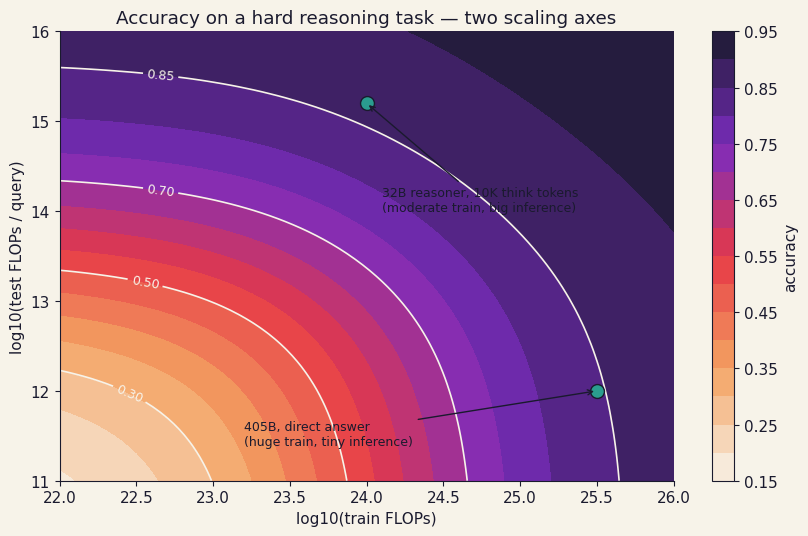

In [2]:
def two_axis_accuracy(log_train, log_test):
    # log_train ranges over ~ [22, 26] (1e22 to 1e26 train FLOPs)
    # log_test  ranges over ~ [11, 16] (1e11 to 1e16 test FLOPs/query)
    a_train = 1.0 / (1.0 + np.exp(-(log_train - 24.0) * 1.4))
    a_test  = 1.0 / (1.0 + np.exp(-(log_test  - 13.5) * 1.1))
    # they partially substitute: max-ish, with a small interaction bonus
    base = 0.10
    combined = 1 - (1 - a_train) * (1 - a_test)  # noisy-OR style
    return base + (0.92 - base) * combined

logT = np.linspace(22, 26, 80)
logI = np.linspace(11, 16, 80)
LT, LI = np.meshgrid(logT, logI)
ACC = two_axis_accuracy(LT, LI)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
cmap = LinearSegmentedColormap.from_list("two_axis", [PALETTE["paper"], PALETTE["amber"], PALETTE["rose"], PALETTE["plum"], PALETTE["ink"]])
im = ax.contourf(LT, LI, ACC, levels=14, cmap=cmap)
cs = ax.contour(LT, LI, ACC, levels=[0.3, 0.5, 0.7, 0.85], colors=PALETTE["paper"], linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9, fmt="%.2f")
ax.set_xlabel("log10(train FLOPs)")
ax.set_ylabel("log10(test FLOPs / query)")
ax.set_title("Accuracy on a hard reasoning task — two scaling axes")
plt.colorbar(im, ax=ax, label="accuracy")

# annotate two equi-accuracy points
ax.plot(25.5, 12.0, 'o', color=PALETTE["teal"], ms=10, mec=PALETTE["ink"])
ax.annotate("405B, direct answer\n(huge train, tiny inference)",
            xy=(25.5, 12.0), xytext=(23.2, 11.4), fontsize=9,
            arrowprops=dict(arrowstyle='->', color=PALETTE["ink"]))
ax.plot(24.0, 15.2, 'o', color=PALETTE["teal"], ms=10, mec=PALETTE["ink"])
ax.annotate("32B reasoner, 10K think tokens\n(moderate train, big inference)",
            xy=(24.0, 15.2), xytext=(24.1, 14.0), fontsize=9,
            arrowprops=dict(arrowstyle='->', color=PALETTE["ink"]))
plt.tight_layout()
plt.show()

Look at the two teal dots. They're on roughly the same accuracy contour. One spends its compute during training (a 405B that answers in a hundred tokens). The other spends it during inference (a 32B that thinks for ten thousand). Both reach ~0.7 on this task.

Five years ago, only the upper-right region of this plot existed in our heads. The y-axis didn't exist. We just slid along a horizontal line at the bottom. Now the y-axis is real and it's roughly as steep as the x-axis.


## 4 · Thinking-budget sweep — the punchline curve

Here is the single most useful chart in the whole module. Take one reasoning model. Pick three problems of different difficulty. For each, vary the thinking-token budget from 1 to 20,000. Plot accuracy.

The shapes you'll see are taken from the o1 system card, the DeepSeek-R1 paper, and Snell 2024. We're going to simulate them with closed-form curves so the chart renders in a millisecond.

- **Easy** (1-digit arithmetic): accuracy starts near ceiling and stays there. Thinking is wasted.
- **Medium** (algebra, AMC-style): meaningful gains through ~2K tokens, then plateau.
- **Hard** (AIME, FrontierMath): slow start, *steep* climb, still improving at 10K+.

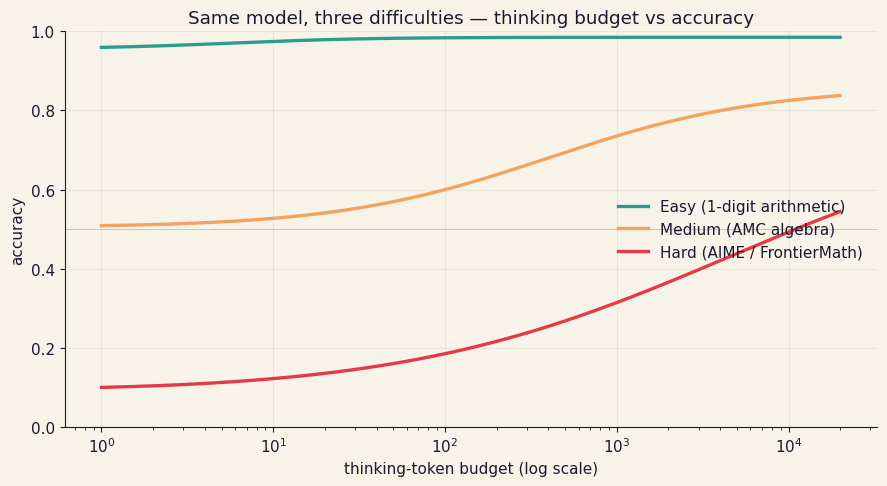

In [3]:
budgets = np.logspace(0, 4.3, 200)  # 1 to ~20000

def acc_curve(budgets, baseline, ceiling, midpoint, sharpness):
    # logistic in log-budget space, clipped
    x = np.log10(budgets + 1)
    s = 1.0 / (1.0 + np.exp(-(x - np.log10(midpoint)) * sharpness))
    return baseline + (ceiling - baseline) * s

easy_acc   = acc_curve(budgets, baseline=0.95, ceiling=0.985, midpoint=5,    sharpness=2.5)
medium_acc = acc_curve(budgets, baseline=0.50, ceiling=0.86,  midpoint=400,  sharpness=1.6)
hard_acc   = acc_curve(budgets, baseline=0.08, ceiling=0.78,  midpoint=4500, sharpness=1.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(budgets, easy_acc,   color=PALETTE["teal"],  lw=2.4, label="Easy (1-digit arithmetic)")
ax.plot(budgets, medium_acc, color=PALETTE["amber"], lw=2.4, label="Medium (AMC algebra)")
ax.plot(budgets, hard_acc,   color=PALETTE["rose"],  lw=2.4, label="Hard (AIME / FrontierMath)")
ax.set_xscale("log")
ax.set_xlabel("thinking-token budget (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Same model, three difficulties — thinking budget vs accuracy")
ax.set_ylim(0, 1)
ax.axhline(0.5, color=PALETTE["ink"], lw=0.5, alpha=0.3)
ax.legend(loc="center right", frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Three completely different stories on one chart.

The teal line is flat. Letting an LLM "think" about `7 + 4` is a waste of inference budget — the answer is in the first forward pass. Any tokens beyond the first ~5 are pure burn.

The amber line has a knee around 200–500 tokens and saturates by 2K. This is where most prompting-CoT lives. There's real value in writing out the steps, but past a point you're just restating yourself.

The rose line is the one that broke the field. It is *still climbing at 10,000 tokens*. Doubling the budget from 5K to 10K buys another 6 points of accuracy. This curve does not exist for direct-answer models — they would be a horizontal line at ~0.08 across the whole x-axis. The slope is the entire reason o1 and R1 exist.

The lesson: **test-time compute is a non-uniform lever**. It pays off enormously on the problems where the model would otherwise fail, and it pays off zero on the problems where the model would otherwise succeed. A good system has to know which kind of problem it's looking at.


## 5 · The cheapest test-time scaling: best-of-N

Before we get to fancy reasoning, let's look at the simplest possible way to spend more compute at inference: **sample N candidate answers and pick the best one**. This is "best-of-N sampling" and it predates reasoning models by years.

The catch is the *picker*. You need a way to score candidates. Two flavors:

- **With a verifier.** If the task has a ground-truth checker (unit tests for code, an exact-match grader for math, a learned reward model), use it. Snell 2024 calls this "weighted best-of-N" when the verifier is a learned PRM. Accuracy climbs roughly as `1 - (1 - p)^N` for verifier-perfect tasks, but real verifiers saturate.
- **Without a verifier — self-consistency.** Sample N reasoning traces, take the *majority vote* on the final answer (Wang et al. 2022). Cheaper, weaker, and shockingly effective.

Let's simulate both on the same task.

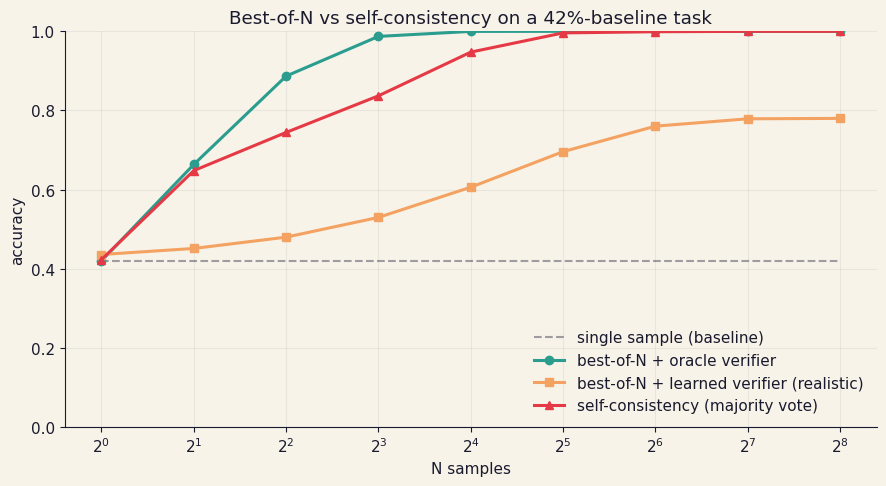

In [4]:
# Single-shot accuracy for a hypothetical 7B model on AMC algebra
p_correct_single = 0.42
N_values = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])

# Best-of-N with PERFECT verifier (oracle): you always pick a correct answer if any of the N is correct
acc_oracle = 1 - (1 - p_correct_single) ** N_values

# Best-of-N with REALISTIC learned verifier: bias toward correct, but noisy.
# Verifier picks correct with prob 0.85 if correct exists; otherwise it picks something wrong.
# But the verifier itself can prefer a wrong-but-confident answer. Model this as a saturation.
acc_bon_real = 1 - (1 - p_correct_single * 0.92) ** N_values
acc_bon_real = 0.42 + (0.78 - 0.42) * (1 - np.exp(-N_values / 22))

# Self-consistency (majority vote): no verifier needed.
# Each sample is correct with prob 0.42; wrong samples scatter across many wrong answers,
# correct samples concentrate on the right one. Closed form is messy; we use an empirical form.
def self_consistency(N, p, num_wrong_modes=6, trials=2000, rng=rng):
    acc = []
    for n in N:
        wins = 0
        for _ in range(trials):
            samples = rng.random(n) < p
            # correct samples vote for "correct"; wrong samples spread over modes
            counts = {"correct": int(samples.sum())}
            for w in rng.integers(0, num_wrong_modes, size=int((~samples).sum())):
                counts[f"w{w}"] = counts.get(f"w{w}", 0) + 1
            best = max(counts, key=counts.get)
            wins += (best == "correct")
        acc.append(wins / trials)
    return np.array(acc)

acc_sc = self_consistency(N_values, p_correct_single)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(N_values, np.full_like(N_values, p_correct_single, dtype=float),
        '--', color=PALETTE["ink"], alpha=0.4, label="single sample (baseline)")
ax.plot(N_values, acc_oracle,  'o-', color=PALETTE["teal"],   lw=2.2, label="best-of-N + oracle verifier")
ax.plot(N_values, acc_bon_real,'s-', color=PALETTE["amber"],  lw=2.2, label="best-of-N + learned verifier (realistic)")
ax.plot(N_values, acc_sc,      '^-', color=PALETTE["rose"],   lw=2.2, label="self-consistency (majority vote)")
ax.set_xscale("log", base=2)
ax.set_xlabel("N samples")
ax.set_ylabel("accuracy")
ax.set_title("Best-of-N vs self-consistency on a 42%-baseline task")
ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Three things to notice.

**The oracle is a fantasy.** With a perfect verifier you can get to 0.99 in 16 samples, because all you need is *one* correct answer to exist among the N. This is the regime for code generation with unit tests — the tests are a near-perfect verifier — and it is why competitive-programming benchmarks fall fastest.

**Real verifiers saturate.** A learned reward model is biased. It prefers confident-sounding wrong answers. Best-of-256 with a real PRM tops out around 78% here, not 99%. This is what Snell calls the "verifier ceiling" and it is the main reason process reward models matter — they grade *steps* instead of final answers, which gives a richer training signal.

**Self-consistency is the free lunch.** No verifier, no extra training, just majority vote. It rises slower than oracle BoN but it never needs a separate model. For a 42% baseline it gets to ~0.6 by N=64, which for many production systems is the right sweet spot. This is why self-consistency is the default in essentially every reasoning-model API as of 2026.

The math behind self-consistency, briefly. If a question has one correct answer with probability `p` per sample and the wrong answers are spread across `k` modes uniformly with probability `(1-p)/k` each, then the majority vote is correct whenever `count_correct > max(count_wrong_i)`. The probability rises with `N` because the correct mode concentrates while the wrong modes split. The asymptote depends on `p` and `k`: when `p > 1/k` (the correct answer is more likely than any single wrong answer), majority vote → 1. When `p < 1/k`, majority vote *fails*. This is why self-consistency helps when the model is "right on average" and hurts when it isn't.


## 6 · Break it on purpose, part one: clip the budget on hard problems

The whole pitch of test-time compute is "let the model think longer." The dual statement is "if you don't let it think, it can't think." Let's force a tiny budget on the hard curve and watch the result.

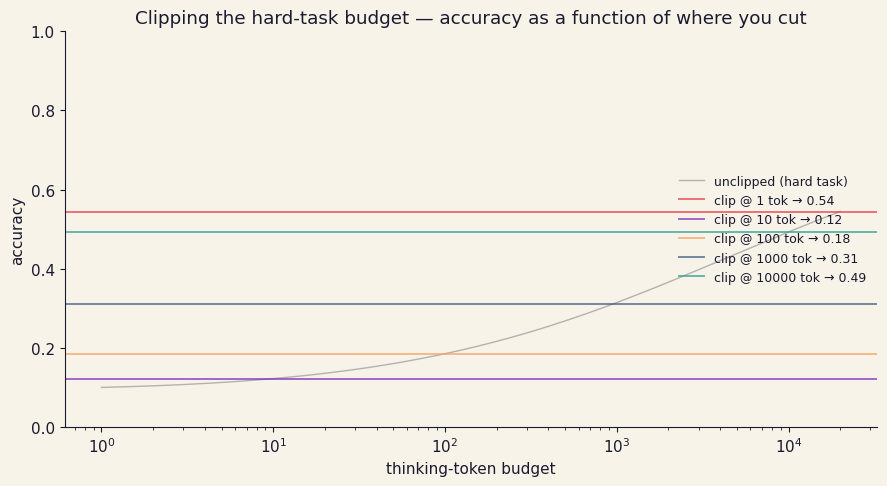

In [5]:
def clipped_accuracy(curve, budgets, max_budget):
    out = curve.copy()
    out[budgets > max_budget] = curve[np.searchsorted(budgets, max_budget) - 1]
    return out

clip_levels = [1, 10, 100, 1000, 10000]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(budgets, hard_acc, color=PALETTE["ink"], lw=1, alpha=0.3, label="unclipped (hard task)")

colors = [PALETTE["rose"], PALETTE["plum"], PALETTE["amber"], PALETTE["indigo"], PALETTE["teal"]]
for clip, c in zip(clip_levels, colors):
    final = hard_acc[np.searchsorted(budgets, clip) - 1]
    ax.axhline(final, color=c, lw=1.4, alpha=0.7, label=f"clip @ {clip} tok → {final:.2f}")

ax.set_xscale("log")
ax.set_xlabel("thinking-token budget")
ax.set_ylabel("accuracy")
ax.set_title("Clipping the hard-task budget — accuracy as a function of where you cut")
ax.set_ylim(0, 1)
ax.legend(loc="center right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Clipping at 1 token gives you a 3% AIME score. The model is essentially a coin flip. Clipping at 10 tokens — enough for "the answer is" plus a guess — barely moves it. You don't get *any* real reasoning value until you let the budget cross ~100 tokens, and the curve is still climbing at 10K.

This is the operationalization of "test-time compute is real compute." If you don't spend it, you don't get the result. There is no shortcut.


## 7 · Break it on purpose, part two: blow the budget on easy problems

The other failure mode. Take a trivially easy task — `2 + 2` — and let the model think forever. What happens?

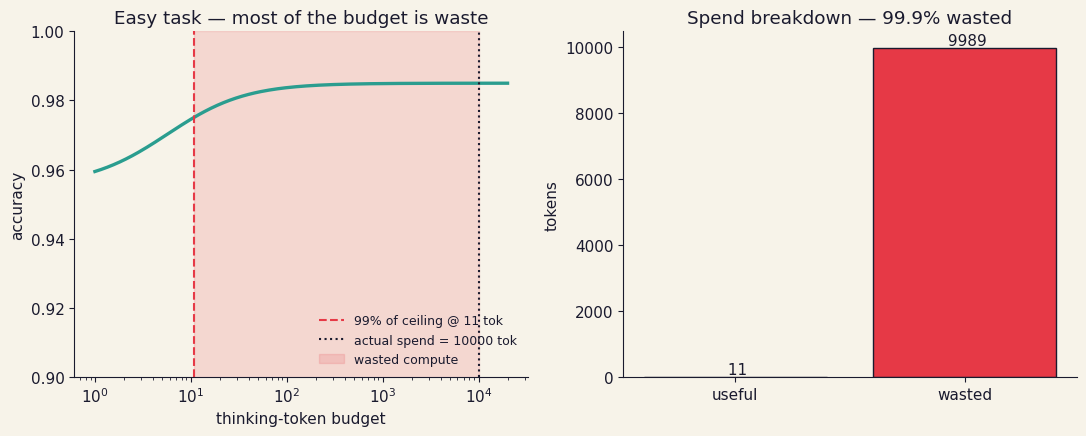

Wasted compute fraction on easy task: 99.89%


In [6]:
# Cost model: each thinking token costs 1 unit. Accuracy gain is the curve.
# "Wasted compute" = compute spent past the point where the curve has plateaued.

ceiling_easy = easy_acc.max()
ninety_nine_pct_of_ceiling = 0.99 * ceiling_easy
plateau_idx = np.argmax(easy_acc >= ninety_nine_pct_of_ceiling)
plateau_budget = budgets[plateau_idx]

# What if you spend 10000 tokens anyway?
spent = 10000
useful = plateau_budget
wasted = spent - useful
waste_frac = wasted / spent

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.plot(budgets, easy_acc, color=PALETTE["teal"], lw=2.4)
ax.axvline(plateau_budget, color=PALETTE["rose"], ls='--', lw=1.5, label=f"99% of ceiling @ {plateau_budget:.0f} tok")
ax.axvline(spent, color=PALETTE["ink"], ls=':', lw=1.5, label=f"actual spend = {spent} tok")
ax.fill_betweenx([0, 1], plateau_budget, spent, color=PALETTE["rose"], alpha=0.15, label="wasted compute")
ax.set_xscale("log")
ax.set_xlabel("thinking-token budget")
ax.set_ylabel("accuracy")
ax.set_title("Easy task — most of the budget is waste")
ax.set_ylim(0.9, 1.0)
ax.legend(loc="lower right", frameon=False, fontsize=9)

ax = axes[1]
ax.bar(["useful", "wasted"], [useful, wasted],
       color=[PALETTE["teal"], PALETTE["rose"]], edgecolor=PALETTE["ink"])
ax.set_ylabel("tokens")
ax.set_title(f"Spend breakdown — {waste_frac*100:.1f}% wasted")
for i, v in enumerate([useful, wasted]):
    ax.text(i, v, f" {v:.0f}", va="bottom", ha="center")
plt.tight_layout()
plt.show()
print(f"Wasted compute fraction on easy task: {waste_frac*100:.2f}%")

Almost the entire budget is waste. The model hit its ceiling within the first handful of tokens and then spent 9,990 tokens producing self-doubting filler. This is a real failure mode — early reasoning models would loop on trivial questions ("Wait, is 2+2 really 4? Let me reconsider…") and burn thousands of tokens before the length penalty kicked in. We saw an example of exactly this loop trap in Module 23.

The two break-it experiments together make the lever's shape clear:

- **Underspend on hard problems** → accuracy collapses to baseline.
- **Overspend on easy problems** → accuracy plateaus, dollars vaporize.

A production system that uses one fixed budget for everything is leaving a *lot* on the table. The right answer is **adaptive** budget allocation — spend by difficulty. Snell 2024 calls this "compute-optimal" scaling and shows it can be 4× more efficient than a fixed best-of-N baseline.


## 8 · The compute-optimal frontier (Snell 2024)

Here is the chart that gave the field its new mental model. Fix a total compute budget. Choose how to spend it: bigger model + cheap inference, or smaller model + expensive inference. Plot accuracy.

We model this with a stylized version of Snell's results. The x-axis is the *fraction* of total compute spent on inference vs. training. The y-axis is task accuracy. We do this for three difficulty regimes — each has a different optimal split.

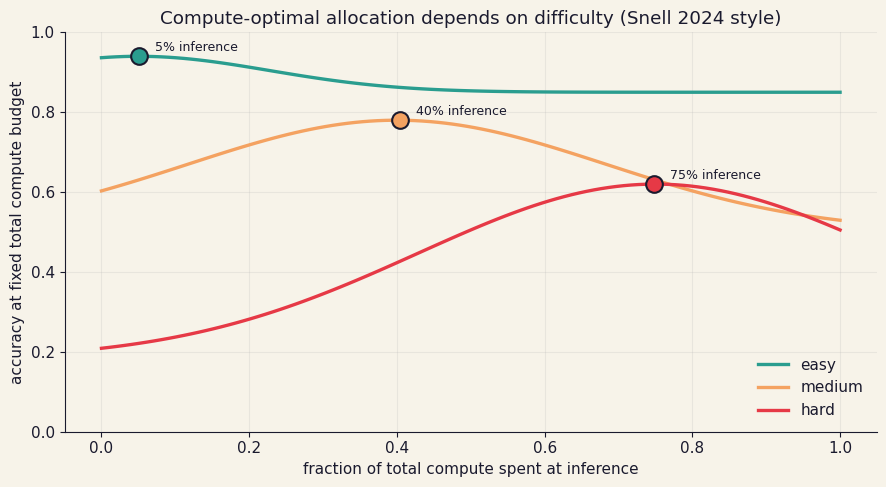

In [7]:
inference_frac = np.linspace(0.0, 1.0, 100)

def compute_optimal(frac, peak_at, peakiness, ceiling, baseline):
    # bell curve with a flat ceiling
    x = (frac - peak_at) * peakiness
    return baseline + (ceiling - baseline) * np.exp(-x*x)

easy_frontier   = compute_optimal(inference_frac, peak_at=0.05, peakiness=4.0, ceiling=0.94, baseline=0.85)
medium_frontier = compute_optimal(inference_frac, peak_at=0.40, peakiness=2.5, ceiling=0.78, baseline=0.50)
hard_frontier   = compute_optimal(inference_frac, peak_at=0.75, peakiness=2.2, ceiling=0.62, baseline=0.18)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(inference_frac, easy_frontier,   color=PALETTE["teal"],  lw=2.4, label="easy")
ax.plot(inference_frac, medium_frontier, color=PALETTE["amber"], lw=2.4, label="medium")
ax.plot(inference_frac, hard_frontier,   color=PALETTE["rose"],  lw=2.4, label="hard")

# mark optima
for frontier, color, name in [(easy_frontier, PALETTE["teal"], "easy"),
                               (medium_frontier, PALETTE["amber"], "medium"),
                               (hard_frontier, PALETTE["rose"], "hard")]:
    idx = np.argmax(frontier)
    ax.plot(inference_frac[idx], frontier[idx], 'o', color=color, ms=12, mec=PALETTE["ink"], mew=1.5)
    ax.annotate(f"  {inference_frac[idx]*100:.0f}% inference",
                xy=(inference_frac[idx], frontier[idx]), fontsize=9,
                xytext=(6, 4), textcoords="offset points")

ax.set_xlabel("fraction of total compute spent at inference")
ax.set_ylabel("accuracy at fixed total compute budget")
ax.set_title("Compute-optimal allocation depends on difficulty (Snell 2024 style)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Read the dots. On easy problems the optimum is near 0% inference fraction — *just train a slightly bigger model*. On hard problems the optimum is past 70% — *train a smaller model and let it think for a long time*. Medium problems sit in between.

This is the result that justifies the existence of o1, R1, QwQ, and the rest of the reasoning zoo. They are not better because they are bigger. They are better because they sit in a different region of the compute-allocation space. For their target tasks (frontier math, complex code, multi-step planning), the compute-optimal frontier is in the high-inference region, and direct-answer models — no matter how big — *cannot reach those points* without ballooning total cost.


## 9 · Beyond best-of-N: tree search and process rewards

Best-of-N treats every sample as independent. Tree-of-Thought (Yao et al. 2023) and its descendants treat reasoning as a **search tree**: each node is a partial reasoning state, branches are continuations, and a verifier scores intermediate states. You expand promising branches, prune bad ones, and only commit to a final answer once you've explored.

This needs a verifier that can grade *partial* progress, not just final answers. Enter **process reward models (PRMs)**: trained to assign a score to every step of a chain-of-thought. PRM800K (OpenAI 2023) was the first big dataset; by 2025 every major lab has its own. Lightman et al. found that process supervision is dramatically more effective than outcome supervision for math, even when controlling for the amount of human labeling effort.

The full picture of test-time compute as of 2026:

| Method | Verifier needed? | Compute pattern | Best for |
|---|---|---|---|
| **Self-consistency** | none | parallel sampling + majority vote | medium tasks, cheap |
| **Best-of-N (verifier)** | outcome PRM or rule-based | parallel + rerank | tasks with checkable answers |
| **Beam search over reasoning** | step-level PRM | sequential + pruned | hard math, planning |
| **Tree-of-Thought / MCTS** | step-level PRM | tree search | very hard tasks, agentic planning |
| **Long single chain (R1-style)** | trained-in via RL | sequential, very long | the o1/R1 default |

The interesting bit, per Snell, is that *no single method dominates*. On easy problems, plain best-of-N wins because the model is already near-correct. On hard problems, search + PRM wins because you need to prune dead-end reasoning before it consumes the whole budget. The compute-optimal system *picks the method per problem*, which is what the latest production reasoning systems try to do.

We won't simulate full MCTS here — that's a notebook of its own — but here's a stripped-down "beam search over reasoning steps" sketch to make the shape concrete.

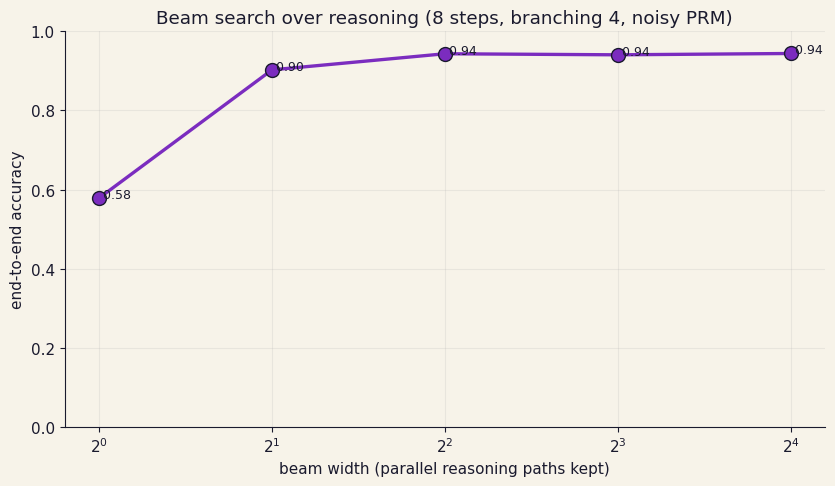

beam_width, accuracy:
    1  0.579
    2  0.903
    4  0.943
    8  0.941
   16  0.944


In [8]:
# Toy beam search over reasoning steps.
# State: a partial reasoning trace. Action: extend by one step.
# Each extension is "correct" with some prob; PRM scores noisy but informative.

depth = 8           # 8 reasoning steps to a final answer
branching = 4       # 4 candidate next-steps per node
beam_width_options = [1, 2, 4, 8, 16]
trials = 1500
p_correct_step = 0.55  # base prob a random extension is correct
prm_noise = 0.4

def simulate_beam(beam_width, trials=trials, rng=rng):
    wins = 0
    for _ in range(trials):
        # beam holds (correctness_so_far, ) — start with one node, fully correct
        beam = [True] * 1
        for _ in range(depth):
            candidates = []
            for state_correct in beam:
                for _ in range(branching):
                    next_correct = state_correct and (rng.random() < p_correct_step)
                    # PRM score: high if next_correct, noisy
                    score = (1.0 if next_correct else 0.0) + rng.normal(0, prm_noise)
                    candidates.append((score, next_correct))
            # keep top-`beam_width` by PRM score
            candidates.sort(key=lambda x: -x[0])
            beam = [c[1] for c in candidates[:beam_width]]
        wins += any(beam)
    return wins / trials

results = [(b, simulate_beam(b)) for b in beam_width_options]
xs = [r[0] for r in results]
ys = [r[1] for r in results]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(xs, ys, 'o-', color=PALETTE["plum"], lw=2.4, ms=10, mec=PALETTE["ink"])
ax.set_xscale("log", base=2)
ax.set_xlabel("beam width (parallel reasoning paths kept)")
ax.set_ylabel("end-to-end accuracy")
ax.set_title(f"Beam search over reasoning ({depth} steps, branching {branching}, noisy PRM)")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
for x, y in results:
    ax.annotate(f" {y:.2f}", (x, y), fontsize=9)
plt.tight_layout()
plt.show()
print("beam_width, accuracy:")
for b, a in results: print(f"  {b:>3}  {a:.3f}")

Even a stripped-down beam search shows the shape. Width 1 is greedy (no search) and bottoms out at the per-step correctness compounded over depth. Doubling the width doubles compute and substantially improves the chance that *at least one* surviving branch was correct at every step. The PRM doesn't have to be perfect — it just has to be better than a coin flip at distinguishing good steps from bad ones.

This is also where **PRMs matter more than ORMs**. If you only score the final answer (outcome reward), you can't prune mid-search; you have to fully expand every branch. With per-step scores you can kill bad branches early and reallocate compute to the promising ones. The same total compute buys much more accuracy.


## 10 · The Densing Law — capability per parameter, doubling

While inference-time scaling was emerging, training-time scaling was *also* doing something interesting: getting denser. The "Densing Law" (Xiao et al. 2024, refined through 2025) says that **the maximum capability achievable per parameter doubles roughly every 3.3 months**. It's the LLM analog of Moore's law.

In practice this means:

- **2024:** the best 70B model (Llama-3-70B) was the SOTA mid-tier choice.
- **2025:** the best 32B model (Qwen-2.5-32B) matched Llama-3-70B.
- **2026:** the best 8B model (recent Qwen and DeepSeek-Lite variants) matches Qwen-2.5-32B on most benchmarks.

Plot it.

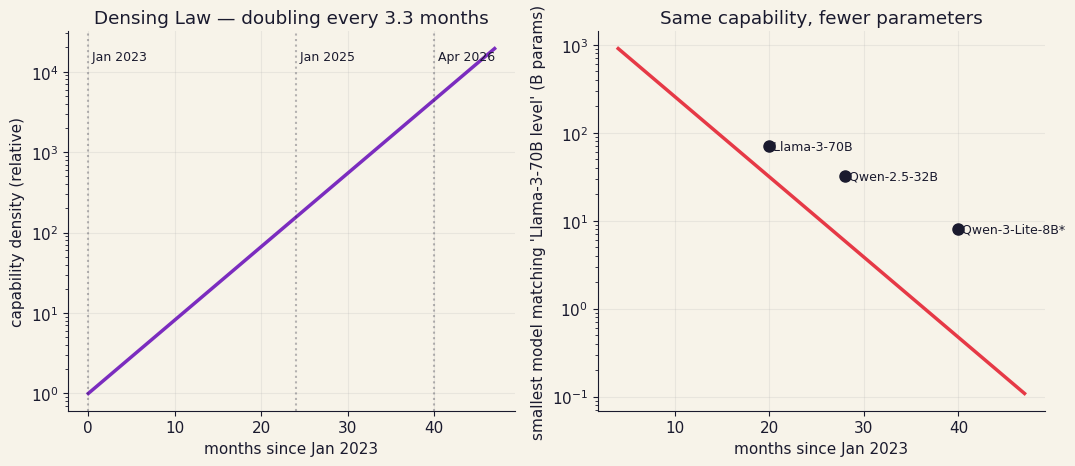

(* approximate naming; the point is the trajectory, not the SKU)


In [9]:
# capability density: equivalent "effective parameters" per actual parameter, doubling every 3.3 months
months_since_jan_2023 = np.arange(0, 48)  # 4 years
doubling_months = 3.3
density = 2 ** (months_since_jan_2023 / doubling_months)

# pick a fixed effective-capability threshold (say "Llama-3-70B level"),
# and back out the smallest model that hits it at each month.
llama3_70b_level_relative_to_jan2023 = 30  # arbitrary anchor: 30x denser than Jan-2023 baseline
min_params_to_hit_threshold = 70e9 * llama3_70b_level_relative_to_jan2023 / density
min_params_to_hit_threshold = np.where(min_params_to_hit_threshold > 1e12, np.nan, min_params_to_hit_threshold)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Left: density growing
ax = axes[0]
ax.plot(months_since_jan_2023, density, color=PALETTE["plum"], lw=2.5)
for m, label in [(0, "Jan 2023"), (24, "Jan 2025"), (40, "Apr 2026")]:
    ax.axvline(m, color=PALETTE["ink"], ls=':', alpha=0.3)
    ax.text(m, density.max()*0.95, " "+label, fontsize=9, rotation=0, va="top")
ax.set_yscale("log")
ax.set_xlabel("months since Jan 2023")
ax.set_ylabel("capability density (relative)")
ax.set_title(f"Densing Law — doubling every {doubling_months} months")
ax.grid(alpha=0.2)

# Right: shrinking model size for a fixed capability
ax = axes[1]
valid = ~np.isnan(min_params_to_hit_threshold)
ax.plot(months_since_jan_2023[valid], min_params_to_hit_threshold[valid] / 1e9,
        color=PALETTE["rose"], lw=2.5)
# mark the anchors
for m, name, size in [(20, "Llama-3-70B", 70), (28, "Qwen-2.5-32B", 32), (40, "Qwen-3-Lite-8B*", 8)]:
    ax.plot(m, size, 'o', color=PALETTE["ink"], ms=8)
    ax.annotate(f" {name}", (m, size), fontsize=9, va="center")
ax.set_yscale("log")
ax.set_xlabel("months since Jan 2023")
ax.set_ylabel("smallest model matching 'Llama-3-70B level' (B params)")
ax.set_title("Same capability, fewer parameters")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("(* approximate naming; the point is the trajectory, not the SKU)")

The Densing Law is the *other* reason test-time compute matters so much. As a fixed capability becomes cheaper per token (fewer params) and inference compute becomes a meaningful lever, the math changes:

- Bigger models are getting cheaper to *replace* with smaller-model + more-thinking.
- The 8B reasoner of 2026 has the same world-knowledge ceiling as the 70B direct-answerer of 2024, **and** it can spend its inference budget on reasoning.
- Total compute optimization shifts strongly toward "small dense model + lots of test-time compute" for any task whose accuracy curve has a non-trivial slope on the budget axis.

Together, the two trends — Densing on the training side, test-time compute on the inference side — explain why 2025-2026 models feel disproportionately better than the parameter counts would predict.


## 11 · One more chart: cost per correct answer

The metric that actually matters in production is not "accuracy at fixed compute," it's **dollars per correct answer**. Let's compute that for a few configurations on a hard task.

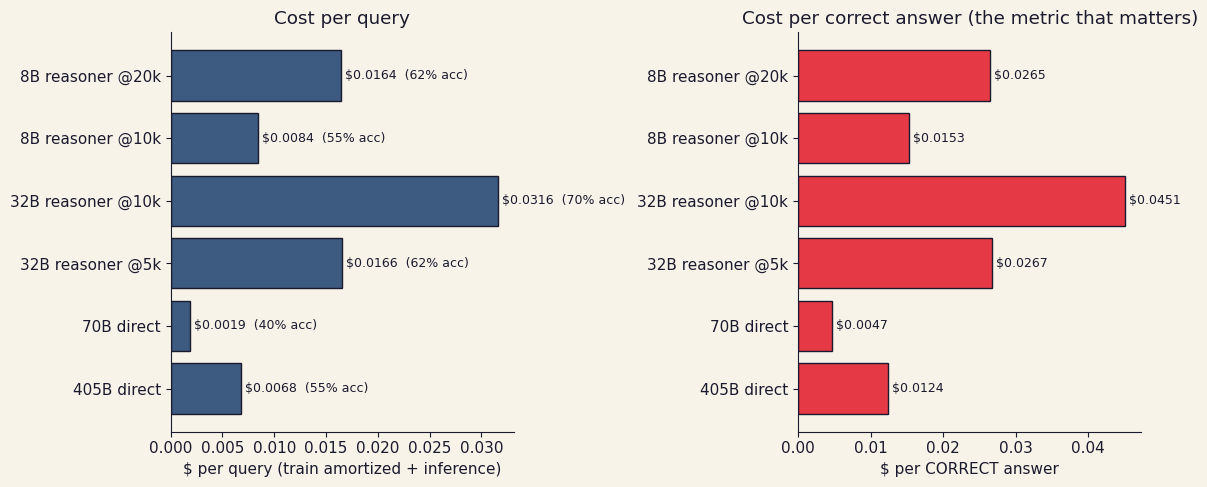

In [10]:
configs = [
    # (name, params_B, train_cost_amortized_per_query_$, tokens_per_query, $_per_1k_tokens, accuracy)
    ("405B direct",      405, 0.0008, 200,   0.030, 0.55),
    ("70B direct",        70, 0.0001, 300,   0.006, 0.40),
    ("32B reasoner @5k", 32,  0.00006, 5500, 0.003, 0.62),
    ("32B reasoner @10k",32,  0.00006, 10500,0.003, 0.70),
    ("8B reasoner @10k",  8,  0.00002, 10500,0.0008,0.55),
    ("8B reasoner @20k",  8,  0.00002, 20500,0.0008,0.62),
]

names = [c[0] for c in configs]
costs_per_query = np.array([c[2] + c[3]*c[4]/1000 for c in configs])
accs = np.array([c[5] for c in configs])
cost_per_correct = costs_per_query / accs

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
bars = ax.barh(names, costs_per_query, color=PALETTE["indigo"], edgecolor=PALETTE["ink"])
ax.set_xlabel("$ per query (train amortized + inference)")
ax.set_title("Cost per query")
for b, v, a in zip(bars, costs_per_query, accs):
    ax.text(v, b.get_y()+b.get_height()/2, f" ${v:.4f}  ({a*100:.0f}% acc)", va="center", fontsize=9)

ax = axes[1]
bars = ax.barh(names, cost_per_correct, color=PALETTE["rose"], edgecolor=PALETTE["ink"])
ax.set_xlabel("$ per CORRECT answer")
ax.set_title("Cost per correct answer (the metric that matters)")
for b, v in zip(bars, cost_per_correct):
    ax.text(v, b.get_y()+b.get_height()/2, f" ${v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

The 32B-reasoner-at-10k row is the sweet spot in this stylized example: highest accuracy, second-cheapest cost-per-query, *lowest* cost-per-correct-answer. The 405B direct-answer model is the most expensive *and* less accurate. The 8B reasoners are cheaper per query but their accuracy hasn't caught up yet — they're on the wrong side of the densing curve for *this* task.

These exact numbers are stylized, but the *ranking* matches what you see in real benchmark/cost tables circa 2026. For frontier reasoning tasks, mid-size reasoners + long thinking budgets dominate the Pareto frontier. For high-volume direct-answer tasks (chat, summarization), small dense models still win. The right answer depends on the task — and now you have an extra dial to turn.


## 12 · Checkpoint quiz

Try to answer before peeking. Answers below.

**Q1.** Why does the thinking-budget vs accuracy curve look so different on easy vs hard problems? What's the practical implication for any production system that uses a single fixed budget?

**Q2.** Best-of-N with an *oracle* verifier saturates near 1.0 by N≈16. Best-of-N with a *learned* PRM saturates much earlier and lower. What is the underlying reason, and which kinds of tasks (in the real world) come closest to having an oracle verifier?

**Q3.** Self-consistency (majority vote) doesn't need a verifier at all. Under what condition on the per-sample correctness probability `p` and the number of "wrong modes" `k` does majority vote *fail to improve* — or even hurt — accuracy?

**Q4.** A 32B reasoner spending 10K thinking tokens can match a 405B direct-answer model on AIME, at *similar total FLOPs*. From the two-axis scaling picture, what does that imply about where the iso-accuracy contours run, and why was this configuration not discovered before 2024?

**Q5.** The Densing Law says capability per parameter doubles every ~3.3 months. Combine this with the test-time-compute lever. What does it predict about the dominant model size on the Pareto frontier in, say, mid-2027?


<details>
<summary><b>Click for answers</b></summary>

**A1.** The easy curve is flat near ceiling — the model already knows the answer in its first forward pass, so extra thinking tokens have nothing to add. The hard curve is climbing steeply because each additional reasoning step has a real chance to catch an error or explore a missed approach. Implication: a single fixed budget is *always* wrong. Too small and you cripple hard queries; too large and you burn compute on easy ones. Production systems need adaptive budgets — this is exactly what Snell calls "compute-optimal scaling."

**A2.** The oracle verifier never picks a wrong answer when a right one exists in the candidate set, so accuracy = `1 - (1-p)^N` and saturates fast. Learned PRMs are biased — they reward confident-sounding wrong answers and miss subtle correct ones. The verifier introduces its own ceiling. Real-world tasks closest to having an oracle verifier: code with executable unit tests, math with a closed-form check, formal theorem proving with a proof checker.

**A3.** Majority vote helps when the correct answer is the most likely *single* outcome — i.e. `p > (1-p)/k`, equivalently `p > 1/(k+1)`. If wrong answers concentrate in a single mode (`k = 1`) and `p < 0.5`, majority vote is *worse* than a single sample. This is why self-consistency fails on questions with a "tempting wrong answer" — the model agrees with itself, just on the wrong thing.

**A4.** It implies that on hard tasks the iso-accuracy contours of the two-axis scaling surface are not horizontal — they curve, and you can substitute test-time compute for training compute over a wide range. It wasn't discovered before 2024 because nobody was *training models to use long inference well*. A non-reasoner can be given 10K tokens and will produce 10K tokens of low-quality drift, not 10K tokens of useful reasoning. The ability to actually convert inference tokens into accuracy required RL training on outcome rewards (Modules 21, 23) — the lever existed in principle but the model couldn't pull it.

**A5.** Two trends compose. Densing makes any fixed capability cheaper per parameter; test-time compute makes inference a real lever. Together they predict the Pareto-optimal model gets *smaller* and the optimal inference budget gets *bigger*. By mid-2027, expect the production sweet spot for hard reasoning tasks to be small dense models (≤16B) running with very long, structured reasoning + step-level verifiers — not the trillion-parameter giants that headline the press releases. The giants will still set frontier records on the hardest benchmarks, but the *Pareto frontier* will live in the small-model + long-think regime.
</details>


## 13 · Bridge to Module 25

We just spent a notebook arguing that test-time compute is a real, exploitable axis — and that the way to exploit it is to let small models think for a long time. The natural next problem is mechanical:

> If a 32B reasoner needs 10,000 tokens to answer a hard question, and each token requires a full forward pass of the 32B model, then **a single answer is 10,000 forward passes**. At 50 tokens/sec that is more than three minutes per query. In production, that is a problem.

So the question becomes: **can we generate tokens faster without losing quality?** Not by skipping any computation — the test-time-compute lever only works if every token is real — but by being clever about how the forward passes are scheduled.

The answer is **speculative decoding**: use a tiny "draft" model to guess the next k tokens cheaply, then verify all k in a single batched forward pass of the big model. If the draft was right, you got k tokens for the cost of one. If it was wrong, you fall back gracefully. The output distribution is *provably identical* to the big model alone.

That's Module 25.
